In [207]:
import numpy as np

project_root = "U:/ML_project/Bargh_ML"
import pandas as pd
import os
import matplotlib.pyplot as plt


In [334]:
csv_semi_processed_path = os.path.join(project_root, "data", "raw", "PlantsTemperature_View_original.csv")
df_c = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

In [335]:
import  jdatetime
def jalali_to_gregorian_fast(date_str):
    jy, jm, jd = map(int, date_str.split('/'))
    jdate = jdatetime.date(jy, jm, jd)
    gdate = jdate.togregorian()
    return f"{gdate.year}-{gdate.month:02d}-{gdate.day:02d}"

In [336]:
df = df_c[(df_c['PowerPlantCode']==104)]
df = df.sort_values(by=['Date','HourNo'])
df["HourNo"] = df["HourNo"].astype(int)
df["Date"] = df["Date"].apply(jalali_to_gregorian_fast)
df["datetime"] = pd.to_datetime(df["Date"]) + pd.to_timedelta(df["HourNo"],unit='h')
df.head()

,PowerPlantCode,PowerPlantName,Date,Name,InsertDateTime,HourNo,Value,Code,datetime
0,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,1,11.38,SCADAF,2021-03-21 01:00:00
1,104,پرند,2021-03-21,سنسور دمای نیروگاه,1401/05/05-08:59:01.06,1,12.97,TempSens,2021-03-21 01:00:00
2,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,2,10.32,SCADAF,2021-03-21 02:00:00
3,104,پرند,2021-03-21,سنسور دمای نیروگاه,1401/05/05-08:59:01.06,2,9.36,TempSens,2021-03-21 02:00:00
4,104,پرند,2021-03-21,فایل های تولید شده اسکادا,1401/05/05-08:59:01.06,3,11.02,SCADAF,2021-03-21 03:00:00


In [337]:
is_env = df["Code"] == "SCADAF"

In [338]:
df_sen = df[~is_env]
df_env = df[is_env]
len(df_sen),len(df_env)

(26191, 34751)

In [339]:
import numpy as np
a, b = np.unique(df['datetime'].to_numpy(), return_counts=True)
a1, b1 = np.unique(df_env['datetime'].to_numpy(), return_counts=True)
a2, b2 = np.unique(df_sen['datetime'].to_numpy(), return_counts=True)

In [340]:
def show_date(dates):
    dates = dates.copy()
    full_range = pd.date_range(start=dates.min(), end=dates.max(), freq='h')
    df = pd.DataFrame({'datetime': full_range})
    df['Value'] = 0
    df.loc[df['datetime'].isin(dates), 'Value'] = 1
    plt.figure(figsize=(12, 6))
    plt.plot(df['datetime'], df['Value'], drawstyle='steps-post', marker='.')
    plt.xlabel('Date and Time')
    plt.ylabel('Value')
    plt.title('Date and Time Presence')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
    return df[df['Value'] == 0]["datetime"]

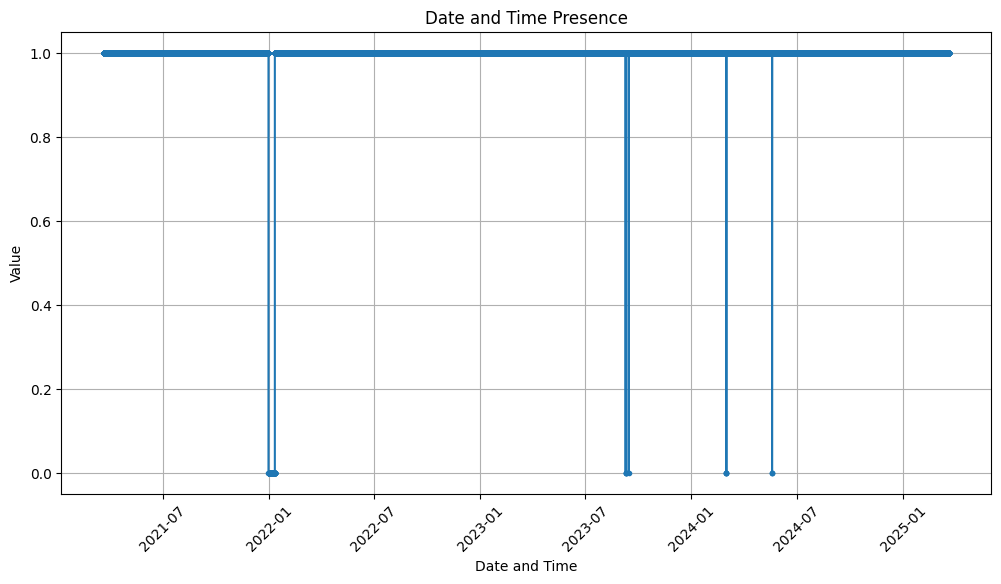

278 16
2021-12-31 23 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-01 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-02 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-03 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-04 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-05 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-06 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-07 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-08 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-09 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20

In [341]:
datestimes = show_date(a)
datess = datestimes.dt.date
print(len(datestimes),len(datess.unique()))
for d in datess.unique():
    t = datestimes[datess == d].dt.hour.to_list()
    print(d,len(t),t)

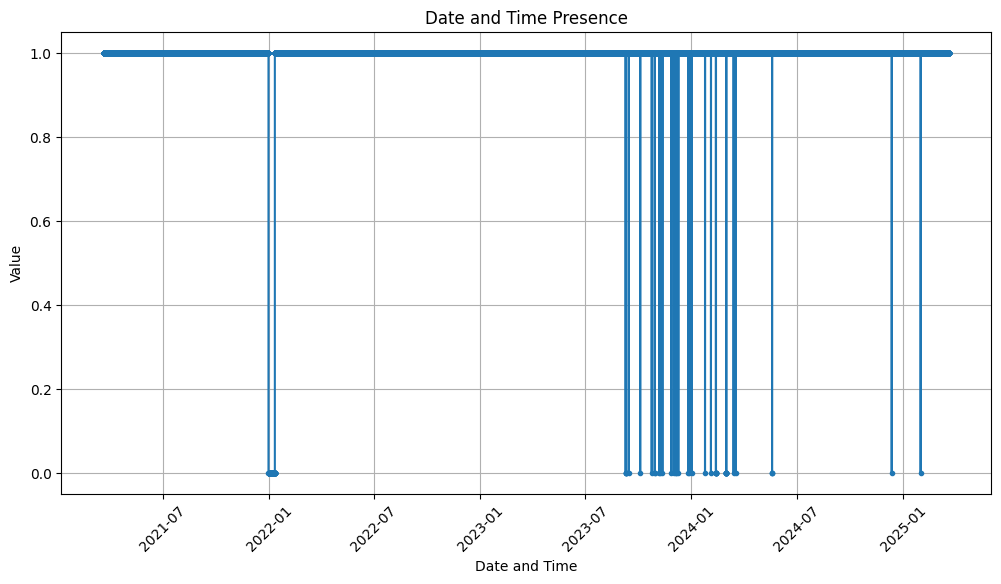

313 38
2021-12-31 23 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-01 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-02 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-03 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-04 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-05 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-06 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-07 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-08 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2022-01-09 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20

In [342]:
datestimes = show_date(a1)
datess = datestimes.dt.date
print(len(datestimes),len(datess.unique()))
for d in datess.unique():
    t = datestimes[datess == d].dt.hour.to_list()
    print(d,len(t),t)

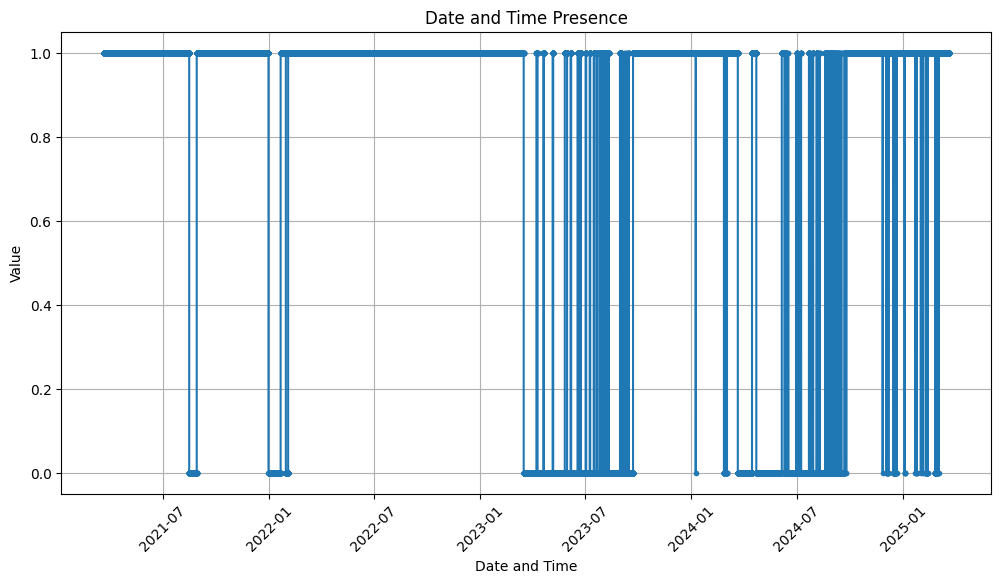

8873 433
2021-08-16 23 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-17 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-18 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-19 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-20 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-21 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-22 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-23 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-24 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2021-08-25 24 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 

In [343]:
datestimes = show_date(a2)
datess = datestimes.dt.date
print(len(datestimes),len(datess.unique()))
for d in datess.unique():
    t = datestimes[datess == d].dt.hour.to_list()
    print(d,len(t),t)

In [344]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df_s = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

In [313]:
t = "1400/01/01"
df_sen = df_sen[df_sen["Date"] == t]
df_env = df_env[df_env["Date"] == t]

In [314]:
tem_sen = df_sen["Value"].values
tem_env = df_env["Value"].values

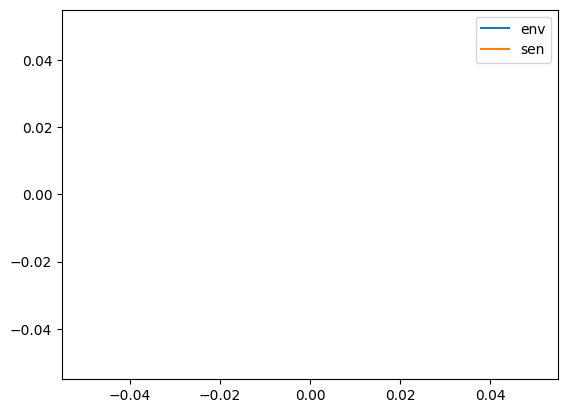

In [315]:

plt.plot(tem_env, label="env")
plt.plot(tem_sen, label='sen')
plt.legend()
plt.show()

In [345]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df_s = pd.read_csv(csv_semi_processed_path, encoding='utf-8')
df_s['date'] = pd.to_datetime(df_s['date'])
df_s['datetime'] = df_s['date'] + pd.to_timedelta(df_s['hour'], unit='h')

In [346]:
df_s2 = df_s[(df_s['name'] == "پرند") & (df_s['code'] == 'G11') & (df_s["is_good_peak"] >= 2)]

,id,name,code,date,hour,temperature,humidity,dew,apparent_temperature,precipitation,...,temperature_with_1_delay,temperature_with_5_delay,humidity_with_1_delay,humidity_with_5_delay,dew_with_1_delay,dew_with_5_delay,surface_pressure_with_1_delay,surface_pressure_with_5_delay,generation_with_24_delay,interval_id
6069,104,پرند,G11,2021-05-22,9,33.828000,9.0,-3.459554,29.278915,0.0,...,32.927998,28.127998,10.0,13.0,-2.721592,-2.888581,893.89500,894.61820,117.73425,0.0
6070,104,پرند,G11,2021-05-22,10,34.427998,9.0,-3.010417,30.306050,0.0,...,33.828000,29.727999,9.0,12.0,-3.459554,-2.718577,893.22590,894.91580,117.70953,0.0
6072,104,پرند,G11,2021-05-22,11,34.828000,8.0,-4.288843,30.287838,0.0,...,34.427998,30.727999,9.0,11.0,-3.010417,-3.117655,892.27484,894.73285,114.42498,0.0
6075,104,پرند,G11,2021-05-22,12,34.828000,9.0,-2.711132,30.118000,0.0,...,34.828000,32.028000,8.0,10.0,-4.288843,-3.404377,891.25476,894.47350,113.15254,0.0
6076,104,پرند,G11,2021-05-22,13,34.828000,9.0,-2.711132,29.337494,0.0,...,34.828000,32.927998,9.0,10.0,-2.711132,-2.721592,890.09940,893.89500,112.36681,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96086,104,پرند,G11,2025-02-20,21,7.231000,44.0,-4.224122,3.888096,0.0,...,7.131000,9.781000,46.0,30.0,-3.722315,-6.992452,889.04090,889.31540,149.17344,NaN
96155,104,پرند,G11,2025-02-23,18,4.331000,52.0,-4.670632,-2.524644,0.0,...,4.931000,7.281000,65.0,57.0,-1.102315,-0.680212,888.75586,887.16890,130.32387,467.0
96156,104,پرند,G11,2025-02-23,19,3.531000,48.0,-6.464019,-3.913896,0.0,...,4.331000,7.231000,52.0,58.0,-4.670632,-0.488457,888.77106,887.06080,130.31151,467.0
96157,104,پرند,G11,2025-02-23,20,2.831000,56.0,-5.088203,-4.151239,0.0,...,3.531000,6.581000,48.0,61.0,-6.464019,-0.407916,888.70220,887.76320,141.46680,467.0


In [349]:
df_merged = pd.merge(df_s, df_sen, on="datetime", how="inner")

In [351]:
len(df_merged), len(df_s)

(4307, 6389)

In [352]:
my_cols = df_merged[['date', 'hour', 'temperature', 'Value', 'generation']]

In [353]:
my_cols.dropna(inplace=True)

C:\Users\S.H.Jasbi\AppData\Local\Temp\ipykernel_14896\99773911.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_cols.dropna(inplace=True)


In [354]:
gens = my_cols['generation'].values
temp_senses = my_cols['Value'].values

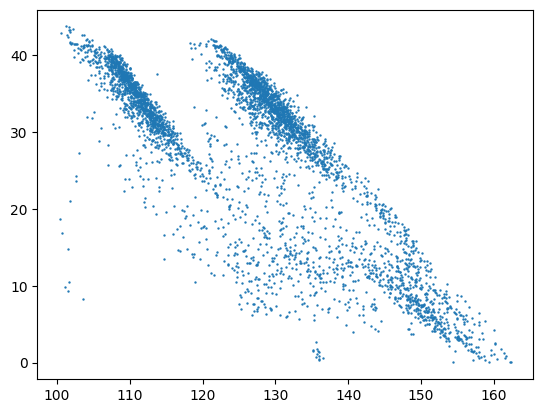

In [355]:
import matplotlib.pyplot as plt

plt.scatter(gens, temp_senses, s=0.5)

plt.show()